In [ ]:
colab = True 

import os 

if colab:
    !git clone https://github.com/mdrs-thiago/PUC_Redes_Neurais
    os.chdir('/content/PUC_Redes_Neurais/pos_grad/lista 2')

# PUC-Rio 
## Departamento de Engenharia Elétrica
## Trabalho 2 - Previsão de séries temporais

Estudante:

Base de dados:

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

import torch 
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler, Dataset, DataLoader 
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

from model_utils import train, train_multi_step_model

from tqdm.notebook import tqdm

## Preparação para a lista

In [2]:
class CustomDataset(Dataset):
    
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data
        
    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]
        
    def __len__ (self):
        return len(self.X_data)

In [3]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    # create model
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)
    #self.out = self.activations[output_activation]
    
    #self.out = nn.Sigmoid() #Para o caso binário
  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    #y = self.out(h2)
    return y

In [4]:
def transform_data(data, lag = 1, test_split = 0.1, normalize = True, category = 'binary'):
    
    '''
    Função para transformação de dados para a 2ª Lista de exercícios.
    A transformação de dados nesta etapa tem duas funções principais: a transformação da série em uma forma tabular para 
    o aprendizado de Redes Neurais e normalização dos dados.
    Parâmetros de entrada:
    - data: base de dados a ser ajeitado.
    - test_split: propoporção da base de dados para teste. Caso seja um float entre 0 e 1, o valor é interpretado como proporção. 
    Caso seja um valor inteiro, é compreendido como o tempo reservado para generalização (e.g. lag = 12 reserva os 12 últimos 
    registros para o teste).
    - normalize: normalização da série. Default True
    - categ: string contendo a codificação a ser realizada para a variável exógena (no caso, o mês).

    A função retorna dois dataframes, sendo o primeiro para treinamento e o segundo para generalização.
    '''

    global _min
    global _max
    
    
    data_values = data.values
    
    if 0 < test_split < 1.0:
        l = data_values.shape[0]
        train_values = data_values[:-int(test_split*l),0].reshape(-1,1)
        test_values = data_values[-int(test_split*l):,0].reshape(-1,1)
        train_idx = data_values[:-int(test_split*l),1].reshape(-1,1)
        test_idx = data_values[-int(test_split*l):,1].reshape(-1,1)
        
    elif test_split > 1 and type(test_split) is int:

        train_values = data_values[:-test_split,0].reshape(-1,1)
        test_values = data_values[-test_split:,0].reshape(-1,1)
        train_idx = data_values[:-test_split,1].reshape(-1,1)
        test_idx = data_values[-test_split:,1].reshape(-1,1)
        
    else:
        print('Test split not understood. Test split should be float between 0 and 1 or integer for index')
    
    assert test_values.shape[0] >= (lag)
    
    _min = np.min(train_values)
    _max = np.max(train_values)
    
    if normalize:
        
        test_values = (test_values - _min)/(_max - _min)
        train_values = (train_values - _min)/(_max - _min)
        
    train_data = np.zeros((train_values.shape[0] - (lag + 1), lag + 2))
    test_data = np.zeros((test_values.shape[0], lag + 2))
    
    
    all_data = np.vstack((train_values,test_values))
    all_idx = np.vstack((train_idx,test_idx))

    new_data = np.zeros((train_values.shape[0] - (lag + 1) + test_values.shape[0],lag + 2))
    
    
    
    for i in range(lag + 2):
        new_data[:,i] = all_data[i:new_data.shape[0]+i,0]
        

    
    if category == 'binary':
        binary_rep = [np.binary_repr(z,width=4) for z in all_idx.astype('int').reshape(-1,)]
        t0 = np.array([int(v) for s in binary_rep for v in s[0]])
        t1 = np.array([int(v) for s in binary_rep for v in s[1]])
        t2 = np.array([int(v) for s in binary_rep for v in s[2]])
        t3 = np.array([int(v) for s in binary_rep for v in s[3]])
        t = np.vstack((t0,t1,t2,t3)).T
        t = t[-new_data.shape[0]:,:]
        temp_idx = [f'month_{i}' for i in range(4)]
        
    elif category == '1toN':
        pass
    
    else:
        t = (all_idx - np.min(train_idx))/(np.max(train_idx) - np.min(train_idx))
        t = t.reshape(-1,1)
        t = t[-new_data.shape[0]:,:]
        temp_idx = ['month']
    
    
    new_data = np.hstack((t,new_data))
    
    train_data = new_data[:-test_values.shape[0],:]
    test_data = new_data[-test_values.shape[0]:,:]
    
    
    data_columns = [f'y(t{i})' if i < 0 else 'y(t)' if i == 0 else f'y(t+{i})' for i in range(-lag,2)] 
    temp_idx.extend(data_columns)
    new_train_df = pd.DataFrame(train_data, columns=temp_idx)
    new_test_df = pd.DataFrame(test_data, columns=temp_idx)
    
    return new_train_df, new_test_df

In [5]:
dataset_name = 'microclima1'
path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/s_{dataset_name}.csv'
raw_data = pd.read_csv(path)

## Parte I - Compreensão do problema

Total: 3,0 pts.

#### 1.	Visualize, em forma de gráfico, a dinâmica temporal da série escolhida. A série é adequada para a modelagem usando Redes Neurais? Caso não seja, que técnicas podem ser aplicadas para ajustar o comportamento da série?

In [7]:
raw_data

,value,time
0,42.001613,1.0
1,42.300000,2.0
2,39.791935,3.0
3,35.808333,4.0
4,29.591935,5.0
...,...,...
139,29.095161,8.0
140,33.425000,9.0
141,32.254839,10.0
142,40.753333,11.0


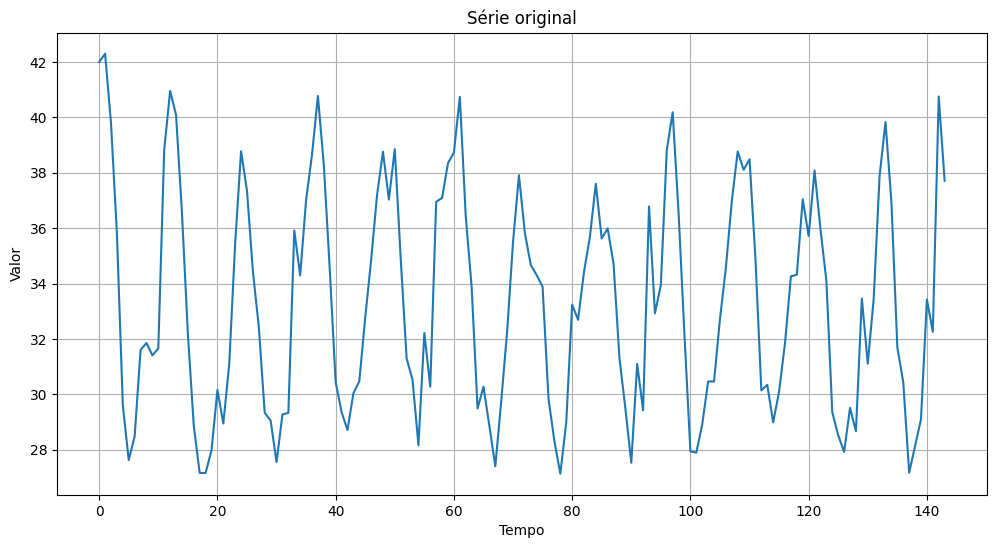

In [7]:
plt.figure(figsize=(12,6))
plt.plot(raw_data['value'])
plt.title('Série original')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid()
plt.show()

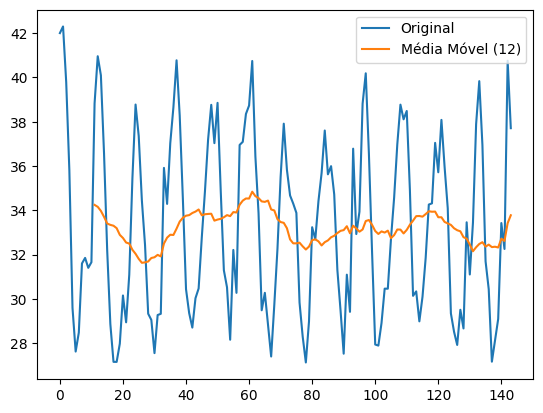

In [8]:
raw_data['moving_avg'] = raw_data['value'].rolling(window=12).mean()
plt.plot(raw_data['value'], label='Original')
plt.plot(raw_data['moving_avg'], label='Média Móvel (12)')
plt.legend()
plt.show()

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(raw_data['value'], period=12)
result.trend.plot(title='Tendência')
result.seasonal.plot(title='Componente Sazonal')

ModuleNotFoundError: No module named 'statsmodels'

In [11]:
sazonal_var = np.var(result.seasonal.dropna())
total_var = np.var(raw_data['value'])
print(f'Proporção da variância sazonal: {sazonal_var/total_var:.2f}')

Proporção da variância sazonal: 0.79


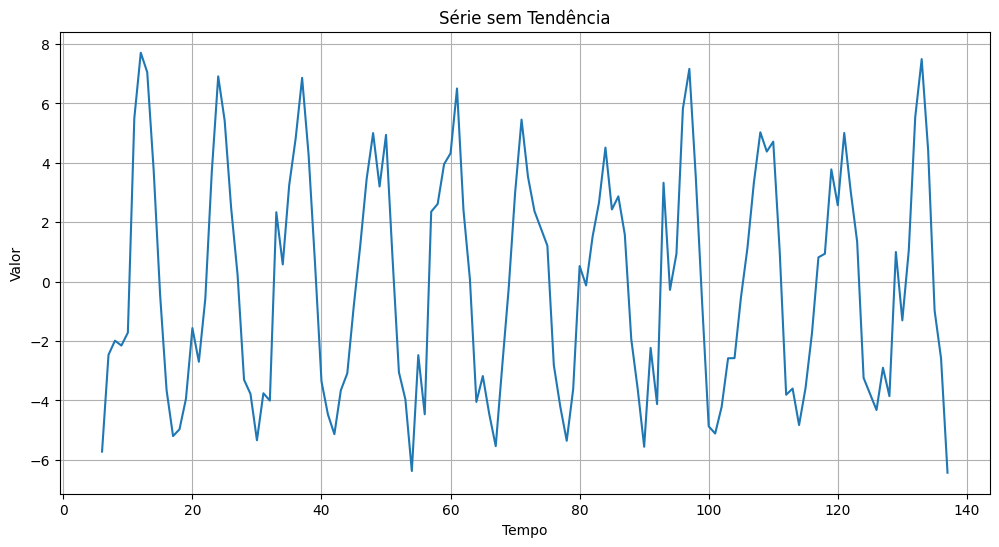

In [12]:
serie_sem_tendencia = raw_data['value'] - result.trend
plt.figure(figsize=(12,6))
plt.plot(serie_sem_tendencia, label='Série sem Tendência')
plt.title('Série sem Tendência')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid()
plt.show()

In [13]:
from scipy.stats import linregress

trend = result.trend.dropna()
slope, intercept, r_value, p_value, std_err = linregress(range(len(trend)), trend)
print(f"Inclinação: {slope:.4f}, R²: {r_value**2:.4f}")

Inclinação: -0.0014, R²: 0.0060


Não. Pois falta retirar a tendência da série temporal. A tendência em uma série temporal pode prejudicar o aprendizado pois impossibilita o modelo de aprender variações sutis nos dados, focando apenas em tendências crsscentes ou decrescentes de longo prazo. Além disso, remover a tendência torna o processo estocástico mais estacionário, mantendo métricas estatiśticas média e variância constantes e covariância invariantes a deslocamento.

#### 2.	Nesta 2ª lista de exercícios, usaremos uma variável exógena que representa o mês de previsão (i.e. no instante t+1). De que forma esta variável pode auxiliar na previsão da série temporal?

Como nosso conjunto de dados consiste nas temperaturas ao longo do tempo, esperamos que ao usar uma variável exógena representando o mês ajudemos na previsão da temperatura, pois sabemos que o mês atual está relacionado com as estações do ano e consequentemente à temperatura.

#### 3. Observe que a base de dados não está em um formato adequado para o uso imediato de um modelo de Rede Neural para previsão de séries temporais. Descreva as etapas necessárias de transformação desta base de dados para que possamos utilizá-la no treinamento de uma MLP. Considere que os padrões de entrada (e saída) devem ser normalizados.

É necessário definir as janelas de entrada e horizonte de previsão adequados e gerar várias amostras a partir dessas janelas deslizantes ao longo do ponto.

## Parte 2 - Previsão one-step

Total: 2,0 pts

<b> IMPORTANTE! </b> Este processo não é a previsão multi-step, conforme ensinado em sala de aula. 
Esta parte da lista é importante para evitar erros de avaliação para a previsão de séries temporais com um horizonte de previsão maior que 1.

#### 1.	Execute o script para a previsão one-step. Avalie o resultado (conjunto de treinamento e teste) usando métricas apropriadas, como RMSE e MAE.

In [14]:
prev = 12
train_val ,test_val = transform_data(raw_data,lag=12,test_split = prev,normalize=True,category='binary')

In [15]:
train_val

,month_0,month_1,month_2,month_3,y(t-12),y(t-11),y(t-10),y(t-9),y(t-8),y(t-7),y(t-6),y(t-5),y(t-4),y(t-3),y(t-2),y(t-1),y(t),y(t+1)
0,0.0,0.0,1.0,0.0,0.980330,1.000000,0.834666,0.572063,0.162272,0.032500,0.088908,0.294752,0.311236,0.281674,0.298381,0.771084,0.911432,0.854621
1,0.0,0.0,1.0,1.0,1.000000,0.834666,0.572063,0.162272,0.032500,0.088908,0.294752,0.311236,0.281674,0.298381,0.771084,0.911432,0.854621,0.622018
2,0.0,1.0,0.0,0.0,0.834666,0.572063,0.162272,0.032500,0.088908,0.294752,0.311236,0.281674,0.298381,0.771084,0.911432,0.854621,0.622018,0.333649
3,0.0,1.0,0.0,1.0,0.572063,0.162272,0.032500,0.088908,0.294752,0.311236,0.281674,0.298381,0.771084,0.911432,0.854621,0.622018,0.333649,0.114426
4,0.0,1.0,1.0,0.0,0.162272,0.032500,0.088908,0.294752,0.311236,0.281674,0.298381,0.771084,0.911432,0.854621,0.622018,0.333649,0.114426,0.001846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,1.0,0.0,0.0,0.0,0.122400,0.195764,0.310928,0.469974,0.473621,0.653596,0.566091,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849
115,1.0,0.0,0.0,1.0,0.195764,0.310928,0.469974,0.473621,0.653596,0.566091,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277
116,1.0,0.0,1.0,0.0,0.310928,0.469974,0.473621,0.653596,0.566091,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237
117,1.0,0.0,1.0,1.0,0.469974,0.473621,0.653596,0.566091,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905


In [16]:
test_val

,month_0,month_1,month_2,month_3,y(t-12),y(t-11),y(t-10),y(t-9),y(t-8),y(t-7),y(t-6),y(t-5),y(t-4),y(t-3),y(t-2),y(t-1),y(t),y(t+1)
0,0.0,0.0,0.0,1.0,0.653596,0.566091,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203
1,0.0,0.0,1.0,0.0,0.566091,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316
2,0.0,0.0,1.0,1.0,0.721995,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897
3,0.0,1.0,0.0,0.0,0.582359,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018
4,0.0,1.0,0.0,1.0,0.459338,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018,0.218092
5,0.0,1.0,1.0,0.0,0.146111,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018,0.218092,0.002396
6,0.0,1.0,1.0,1.0,0.091499,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018,0.218092,0.002396,0.065517
7,1.0,0.0,0.0,0.0,0.052226,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018,0.218092,0.002396,0.065517,0.129524
8,1.0,0.0,0.0,1.0,0.156849,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018,0.218092,0.002396,0.065517,0.129524,0.414951
9,1.0,0.0,1.0,0.0,0.101277,0.417237,0.261905,0.416387,0.709203,0.837316,0.646897,0.301018,0.218092,0.002396,0.065517,0.129524,0.414951,0.337813


In [17]:
train_values = train_val.values

X_train = train_values[:,:-1]
y_train = train_values[:,-1]

test_values = test_val.values
X_test = test_values[:,:-1]
y_test = test_values[:,-1]

In [18]:
train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))

test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

In [19]:
batch_size = 32

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)

test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [20]:
n_input = X_train.shape[1]
n_output = 1
hidden_neurons = 20

In [21]:
model = NeuralNetwork(n_input = n_input, n_output=n_output, hidden_neurons=hidden_neurons, hidden_activation='sigmoid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)
lr = 0.05
epochs = 1000

history, y_hat = train(model, train_loader, epochs, device, lr)

cuda


  8%|▊         | 80/1000 [00:01<00:07, 116.48it/s]

Epoch 51/1000, Loss: 0.0292


 12%|█▏        | 120/1000 [00:01<00:05, 153.94it/s]

Epoch 101/1000, Loss: 0.0138


...

Epoch 901/1000, Loss: 0.0080


 97%|█████████▋| 973/1000 [00:06<00:00, 162.76it/s]

Epoch 951/1000, Loss: 0.0079


100%|██████████| 1000/1000 [00:06<00:00, 143.15it/s]

Epoch 1001/1000, Loss: 0.0079


Erro MSE = 2.314 
Erro MAE = 1.19


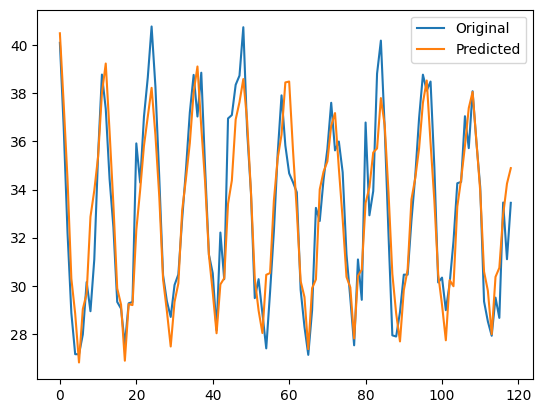

In [22]:
y_pred_tr = model(torch.from_numpy(X_train).float().to(device))
y_hat_tr = y_pred_tr.detach().cpu().numpy()

orig_y_eval = y_train*(_max-_min) + _min
orig_y_hat = y_hat_tr*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

Erro MSE = 6.809 
Erro MAE = 1.846


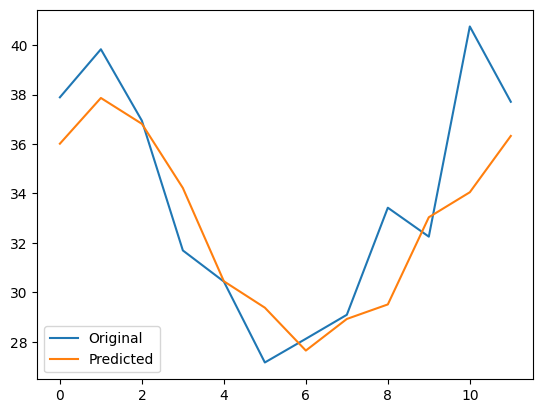

In [23]:
y_pred = model(torch.from_numpy(X_test).float().to(device))
y_hat = y_pred.detach().cpu().numpy()

orig_y_eval = y_test*(_max-_min) + _min
orig_y_hat = y_hat*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

Podemos ver que o modelo aprendeu bem no conjunto de treino, entretanto no conjunto de teste performou um pouco pior. Apesar da falta de generalização o modelo mostrou aprender padrões básicos como tendências de decrescimento e crescimento da série em torno do tempo 5.

#### 2.	Modifique a técnica de codificação mensal de 'binário' para 'numérico'. Qual a mudança existente na arquitetura da Rede Neural? Analise o resultado (conjunto de treinamento e teste), usando as métricas adequadas.

In [24]:
prev = 12
train_val ,test_val = transform_data(raw_data, lag=12, test_split = prev,normalize=True,category='numeric')

In [25]:
train_values = train_val.values

X_train = train_values[:,:-1]
y_train = train_values[:,-1]

test_values = test_val.values
X_test = test_values[:,:-1]
y_test = test_values[:,-1]

In [26]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(119, 14) (119,)
(12, 14) (12,)


In [27]:
train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))

test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

In [28]:
batch_size = 32

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)

test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [29]:
n_input = X_train.shape[1]
n_output = 1
hidden_neurons = 20

model = NeuralNetwork(n_input = n_input, n_output=n_output, hidden_neurons=hidden_neurons, hidden_activation='sigmoid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)
lr = 0.05
epochs = 1000

history, y_hat = train(model, train_loader, epochs, device, lr)

cuda


  0%|          | 0/1000 [00:00<?, ?it/s]

  7%|▋         | 74/1000 [00:00<00:06, 142.94it/s]

Epoch 51/1000, Loss: 0.0302


 12%|█▏        | 123/1000 [00:00<00:06, 145.27it/s]

...

Epoch 901/1000, Loss: 0.0109


 97%|█████████▋| 974/1000 [00:06<00:00, 161.96it/s]

Epoch 951/1000, Loss: 0.0109


100%|██████████| 1000/1000 [00:06<00:00, 153.35it/s]

Epoch 1001/1000, Loss: 0.0108


Erro MSE = 2.659 
Erro MAE = 1.254


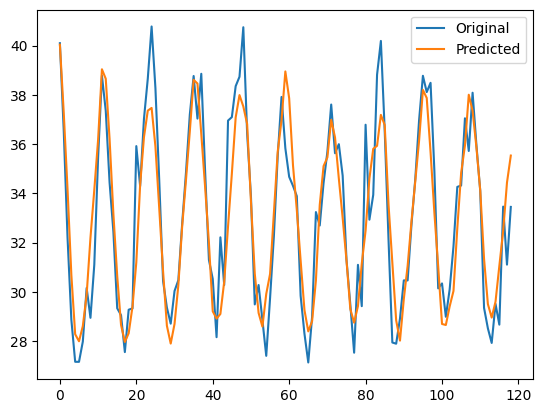

In [30]:
y_pred_tr = model(torch.from_numpy(X_train).float().to(device))
y_hat_tr = y_pred_tr.detach().cpu().numpy()

orig_y_eval = y_train*(_max-_min) + _min
orig_y_hat = y_hat_tr*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

Erro MSE = 6.558 
Erro MAE = 1.759


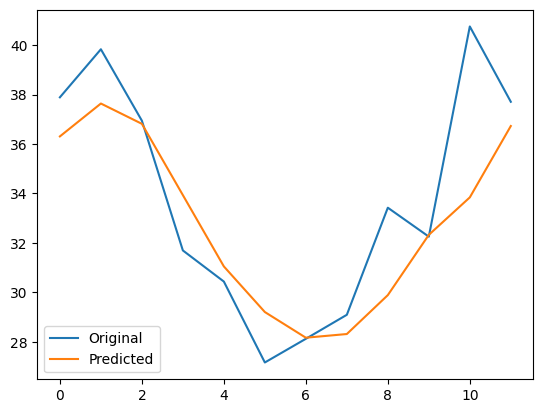

In [31]:
y_pred = model(torch.from_numpy(X_test).float().to(device))
y_hat = y_pred.detach().cpu().numpy()

orig_y_eval = y_test*(_max-_min) + _min
orig_y_hat = y_hat*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

Podemos ver que a codificação mensal numérica é uma modelagem melhor do que a binária, já que o erro de teste foi menor que na questão anterior. Apesar do erro no treino ter sido ligeiramente maior, a curva da série predita em ambos os conjuntos de treino e teste, se apresentaram um pouco mais suavizadas, mostrando que generalizaram mais e 'overfitaram' menos.

## Parte 3 - Previsão multi-step

Total: 5,0 pts.

#### 1.	Esquematize como você implementaria o processo de previsão multi-step. Descreva todos os passos necessários, e em seguida compare com o código fornecido para a previsão. 

In [102]:
def multi_step(model, X_test, cod='numeric', device='cpu', prev=12):
  y_result = []
  X_t = np.copy(X_test[0]) 
  for i in range(prev):
      y_hat = model(torch.from_numpy(X_t).float().to(device))
      
      if cod == 'numeric':

        #Ajeitando a codificação. Transformamos para o valor do mês e somamos 1 (para o próximo passo) e 
        #depois pegamos o resto da divisão por 12 (para que o mês fique sempre entre 0 e 11)
        tmp = int(X_t[0] * 12 + 1) % 12
        
        #Alterando a variável mês
        X_t[0] = tmp/12
        
        #Movendo todos os registros, 'deslizando a janela'
        X_t[1:X_t.shape[0]-1] = X_t[2:]

      elif cod == 'binary':
        pass

      else:
        print('Erro de codificação.')
        break
      

      X_t[-1] = y_hat
      
      y_result.append(y_hat[0].cpu().detach().numpy())
  return np.array(y_result)

Problemas:

- O modelo utiliza uma janela entrada de 12. Não logo a previsão multi-step acaba sendo one-step.

- O código parece usar a janela dezliante na dimensão das amostras e não do tempo

In [103]:
prev = 12
train_val ,test_val = transform_data(raw_data, lag=12, test_split=prev, normalize=True, category='numeric')

In [104]:
print(train_val.head(10))

      month   y(t-12)   y(t-11)   y(t-10)    y(t-9)    y(t-8)    y(t-7)  \
0  0.090909  0.980330  1.000000  0.834666  0.572063  0.162272  0.032500   
1  0.181818  1.000000  0.834666  0.572063  0.162272  0.032500  0.088908   
2  0.272727  0.834666  0.572063  0.162272  0.032500  0.088908  0.294752   
3  0.363636  0.572063  0.162272  0.032500  0.088908  0.294752  0.311236   
4  0.454545  0.162272  0.032500  0.088908  0.294752  0.311236  0.281674   
5  0.545455  0.032500  0.088908  0.294752  0.311236  0.281674  0.298381   
6  0.636364  0.088908  0.294752  0.311236  0.281674  0.298381  0.771084   
7  0.727273  0.294752  0.311236  0.281674  0.298381  0.771084  0.911432   
8  0.818182  0.311236  0.281674  0.298381  0.771084  0.911432  0.854621   
9  0.909091  0.281674  0.298381  0.771084  0.911432  0.854621  0.622018   

     y(t-6)    y(t-5)    y(t-4)    y(t-3)    y(t-2)    y(t-1)      y(t)  \
0  0.088908  0.294752  0.311236  0.281674  0.298381  0.771084  0.911432   
1  0.294752  0.311236  0

In [105]:
train_values = train_val.values
# pred_horizon = 12

X_train = train_values[:,:-1]
y_train = train_values[:,-1]

test_values = test_val.values
X_test = test_values[:,:-1]
y_test = test_values[:,-1]

In [106]:
print(X_train[0])
print(y_train[0])
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

[0.09090909 0.98033003 1.         0.83466593 0.57206297 0.16227193
 0.03249975 0.08890826 0.29475184 0.31123563 0.28167397 0.29838104
 0.77108408 0.91143197]
0.8546206961498539
(119, 14)
(119,)
(12, 14)
(12,)


In [107]:
train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

batch_size = 32
train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

n_input = X_train.shape[1]
n_output = 1
hidden_neurons = 20

model = NeuralNetwork(n_input = n_input, n_output=n_output, hidden_neurons=hidden_neurons, hidden_activation='sigmoid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)
lr = 0.05
epochs = 1000

history, y_hat = train(model, train_loader, epochs, device, lr)

cpu


  9%|▊         | 86/1000 [00:00<00:05, 175.88it/s]

Epoch 51/1000, Loss: 0.0233


 12%|█▏        | 123/1000 [00:00<00:05, 174.99it/s]

Epoch 101/1000, Loss: 0.0133


...

Epoch 901/1000, Loss: 0.0109


 96%|█████████▋| 963/1000 [00:05<00:00, 125.84it/s]

Epoch 951/1000, Loss: 0.0109


100%|██████████| 1000/1000 [00:05<00:00, 170.37it/s]

Epoch 1001/1000, Loss: 0.0109


In [108]:
y_result = multi_step(model, X_test, cod='numeric', device=device)

In [109]:
y_result
print(y_result.shape)

(12,)


Erro MSE = 9.164 
Erro MAE = 2.288


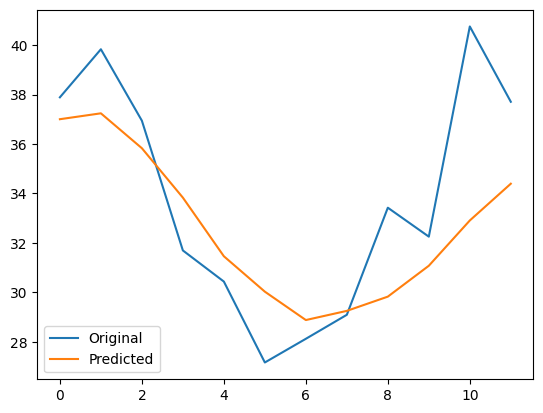

In [110]:
orig_y_eval = y_test*(_max-_min) + _min
orig_y_hat = y_result*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

#### 2.	Faça a previsão multi-step para o horizonte de previsão igual a 12. Perceba que o resultado da métrica é, geralmente, pior do que o apresentado para a previsão one-step. Por quê? É justo comparar o resultado deste item com o que foi apresentado anteriormente? Discuta. 

In [111]:
def multi_step(model, X_test, cod='numeric', device='cpu', prev=12):
  y_result = []
  X_t = np.copy(X_test[0])
  for i in range(prev):
      y_hat = model(torch.from_numpy(X_t).float().to(device))
      
      if cod == 'numeric':

        #Ajeitando a codificação. Transformamos para o valor do mês e somamos 1 (para o próximo passo) e 
        #depois pegamos o resto da divisão por 12 (para que o mês fique sempre entre 0 e 11)
        tmp = int(X_t[0] * 12 + 1) % 12
        
        #Alterando a variável mês
        X_t[0] = tmp/12
        
        #Movendo todos os registros, 'deslizando a janela'
        X_t[1:X_t.shape[0]-1] = X_t[2:]

      elif cod == 'binary':
        pass

      else:
        print('Erro de codificação.')
        break
      

      X_t[-1] = y_hat
      
      y_result.append(y_hat[0].cpu().detach().numpy())
  return np.array(y_result)

In [112]:
prev = 12
train_val ,test_val = transform_data(raw_data, lag=12, test_split=prev, normalize=True, category='numeric')

In [113]:
print(train_val.head(10))

      month   y(t-12)   y(t-11)   y(t-10)    y(t-9)    y(t-8)    y(t-7)  \
0  0.090909  0.980330  1.000000  0.834666  0.572063  0.162272  0.032500   
1  0.181818  1.000000  0.834666  0.572063  0.162272  0.032500  0.088908   
2  0.272727  0.834666  0.572063  0.162272  0.032500  0.088908  0.294752   
3  0.363636  0.572063  0.162272  0.032500  0.088908  0.294752  0.311236   
4  0.454545  0.162272  0.032500  0.088908  0.294752  0.311236  0.281674   
5  0.545455  0.032500  0.088908  0.294752  0.311236  0.281674  0.298381   
6  0.636364  0.088908  0.294752  0.311236  0.281674  0.298381  0.771084   
7  0.727273  0.294752  0.311236  0.281674  0.298381  0.771084  0.911432   
8  0.818182  0.311236  0.281674  0.298381  0.771084  0.911432  0.854621   
9  0.909091  0.281674  0.298381  0.771084  0.911432  0.854621  0.622018   

     y(t-6)    y(t-5)    y(t-4)    y(t-3)    y(t-2)    y(t-1)      y(t)  \
0  0.088908  0.294752  0.311236  0.281674  0.298381  0.771084  0.911432   
1  0.294752  0.311236  0

In [114]:
train_values = train_val.values

X_train = train_values[:,:-1]
y_train = train_values[:,-1]

test_values = test_val.values
X_test = test_values[:,:-1]
y_test = test_values[:,-1]

In [115]:
print(X_train[0])
print(y_train[0])
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

[0.09090909 0.98033003 1.         0.83466593 0.57206297 0.16227193
 0.03249975 0.08890826 0.29475184 0.31123563 0.28167397 0.29838104
 0.77108408 0.91143197]
0.8546206961498539
(119, 14)
(119,)
(12, 14)
(12,)


In [116]:
train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

batch_size = 32
train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

n_input = X_train.shape[1]
n_output = 1
hidden_neurons = 20

model = NeuralNetwork(n_input = n_input, n_output=n_output, hidden_neurons=hidden_neurons, hidden_activation='sigmoid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)
lr = 0.05
epochs = 1000

history, y_hat = train(model, train_loader, epochs, device, lr)

cpu


  8%|▊         | 80/1000 [00:00<00:06, 146.38it/s]

Epoch 51/1000, Loss: 0.0294


 12%|█▏        | 116/1000 [00:00<00:05, 152.68it/s]

Epoch 101/1000, Loss: 0.0155


...

Epoch 901/1000, Loss: 0.0112


 99%|█████████▉| 990/1000 [00:06<00:00, 199.16it/s]

Epoch 951/1000, Loss: 0.0112


100%|██████████| 1000/1000 [00:06<00:00, 158.95it/s]

Epoch 1001/1000, Loss: 0.0112


In [117]:
y_result = multi_step(model, X_test, cod='numeric', device=device)

In [118]:
y_result
print(y_result.shape)
print(y_test.shape)

(12,)
(12,)


Erro MSE = 9.06 
Erro MAE = 2.294


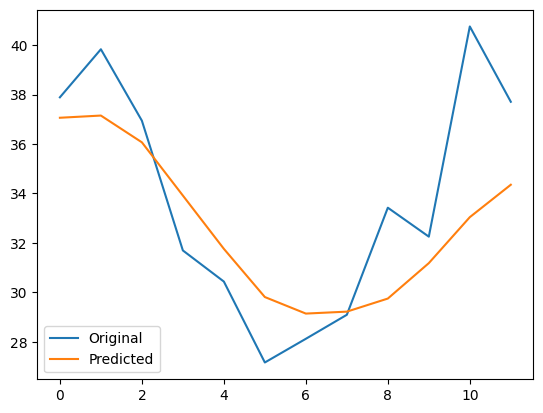

In [119]:
orig_y_eval = y_test*(_max-_min) + _min
orig_y_hat = y_result*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

Podemos ver que o erro aumentou. Isso era esperado visto que o modelo foi treinado para prever apenas o mês seguinte e utilizamos ele de maneira autoregressiva para prever os 12. Isso faz com que o erro se acumule ao longo das previsões, aumentando o valor dele como acabamos de medir.

#### 3.	Modifique o tamanho da janela de entrada do modelo. Analise os resultados, utilizando as métricas adequadas. 

In [24]:
print(X_test.shape)

(12, 14)


In [120]:
def multi_step(model, X_test, cod='numeric', device='cpu', prev=12):
  y_result = []
  X_t = np.copy(X_test[0]) #! Porque só pega a p[rimeira amostra?
  
  for i in range(prev):
      y_hat = model(torch.from_numpy(X_t).float().to(device))
      if cod == 'numeric':

        #Ajeitando a codificação. Transformamos para o valor do mês e somamos 1 (para o próximo passo) e 
        #depois pegamos o resto da divisão por 12 (para que o mês fique sempre entre 0 e 11)
        tmp1 = X_t * 12 + 1
        tmp = tmp1.astype(int) % 12
        
        #Alterando a variável mês
        X_t = tmp/12
        
        #Movendo todos os registros, 'deslizando a janela'
        X_t[1:X_t.shape[0]-1] = X_t[2:]

      elif cod == 'binary':
        pass

      else:
        print('Erro de codificação.')
        break
      
      X_t[-1] = y_hat.cpu().detach().numpy()
      
      y_result.append(y_hat[0].cpu().detach().numpy())
  return np.array(y_result)

In [121]:
prev = 12
train_val ,test_val = transform_data(raw_data, lag=12, test_split=prev, normalize=True, category='numeric')

In [122]:
train_values = train_val.values

input_window = 0
X_train = train_values[:, :-1]
y_train = train_values[:,-1]

test_values = test_val.values
X_test = test_values[:, :-1]
y_test = test_values[:,-1]

In [123]:
train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

batch_size = 32
train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

n_input = X_train.shape[1]
n_output = 1
hidden_neurons = 20

model = NeuralNetwork(n_input = n_input, n_output=n_output, hidden_neurons=hidden_neurons, hidden_activation='sigmoid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)
lr = 0.05
epochs = 1000

history, y_hat = train(model, train_loader, epochs, device, lr)

cpu


  8%|▊         | 78/1000 [00:00<00:05, 162.47it/s]

Epoch 51/1000, Loss: 0.0279


 13%|█▎        | 133/1000 [00:00<00:04, 175.00it/s]

Epoch 101/1000, Loss: 0.0154


...

Epoch 901/1000, Loss: 0.0107


 98%|█████████▊| 978/1000 [00:05<00:00, 197.77it/s]

Epoch 951/1000, Loss: 0.0106


100%|██████████| 1000/1000 [00:05<00:00, 184.59it/s]

Epoch 1001/1000, Loss: 0.0106


In [124]:
y_result = multi_step(model, X_test, cod='numeric', device=device)

C:\Users\Dell\AppData\Local\Temp\ipykernel_4568\1178885855.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_t[-1] = y_hat.cpu().detach().numpy()


In [125]:
print(y_result.shape)
print(y_test.shape)

(12,)
(12,)


Erro MSE = 26.806 
Erro MAE = 4.009


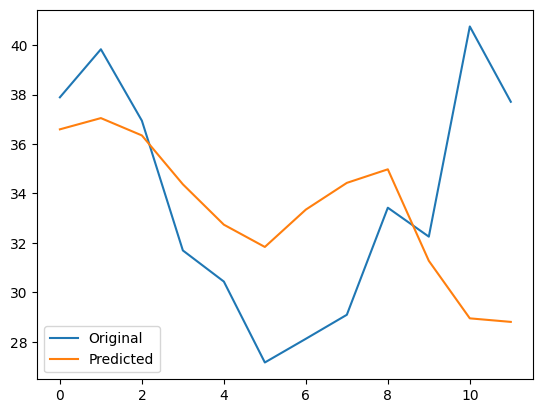

In [126]:
orig_y_eval = y_test*(_max-_min) + _min
orig_y_hat = y_result*(_max-_min) + _min
mae_error = mean_absolute_error(orig_y_eval, orig_y_hat)
mse_error = mean_squared_error(orig_y_eval, orig_y_hat)

plt.plot(orig_y_eval)
plt.plot(orig_y_hat)
plt.legend(['Original','Predicted'])

print(f'Erro MSE = {round(mse_error,3)} \nErro MAE = {round(mae_error,3)}')

O erro aumenta consideravelmente conforme a janela de entrada diminui. Isso faz sentido, pois diminuimos a informação fornecida ao modelo. Quanto menos contexto damos ao modelo pior ele performa.

#### 4.	Modifique a topologia da rede para obter um melhor desempenho. Altere seus parâmetros (e.g. número de processadores na camada escondida, tipo de função na camada de saída) e avalie o desempenho.

In [54]:
prev = 12
train_val ,test_val = transform_data(raw_data, lag=12, test_split=prev, normalize=True, category='numeric')

In [55]:
train_values = train_val.values

input_window = 1
X_train = train_values[:,input_window:-1]
y_train = train_values[:,-1]

test_values = test_val.values
X_test = test_values[:,input_window:-1]
y_test = test_values[:,-1]

In [ ]:
train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))

batch_size = 32
train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

n_input = X_train.shape[1]
n_output = 1
hidden_neurons = 70

model = NeuralNetwork(n_input=n_input, n_output=n_output, hidden_neurons=hidden_neurons, hidden_activation='tanh')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)
lr = 0.05
epochs = 1000

history, y_hat = train(model, train_loader, epochs, device, lr)

KeyError: 'tanh'

#### 5. Modifique a função de previsão multi-step para permitir a codificação binária da variável mês. Em seguida, treine um modelo MLP usando a codificação binária para a variável exógena e faça a previsão multi-step e analise o resultado. 

OBS: Para este item, basta alterar a atualização da variável exógena na condição desejada (no caso, cod = 'binary')